# NIFTY-Sentinel: ablation and explainability
This notebook tests whether each proposed information layer adds out-of-sample value. It then explains the latest warning from the selected tree model.

In [1]:
import os
os.chdir(r'C:\Users\deepa\Documents\ChatGPT\ML 2 porject')
import joblib
import matplotlib.pyplot as plt
import pandas as pd
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, precision_score, recall_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from src.config import FIGURES_DIR, MODELS_DIR, PROCESSED_DATA_DIR

state = pd.read_csv(PROCESSED_DATA_DIR / 'regime_features.csv', parse_dates=['date']).set_index('date')
connected = pd.read_csv(PROCESSED_DATA_DIR / 'connectedness_features.csv', parse_dates=['date']).set_index('date')
dataset = state.join(connected, how='left')
TARGET = 'stress_next_10d'
labeled = dataset.dropna(subset=[TARGET]).copy()
y = labeled[TARGET].astype(int)
print('Labeled rows:', len(labeled), '| Stress prevalence:', y.mean().round(3))

Labeled rows: 4095 | Stress prevalence: 0.169


C:\Users\deepa\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# The groups map directly to the four research components in the proposal.
available = set(dataset.select_dtypes('number').columns) - {TARGET, 'nifty_close'}
market = sorted(c for c in available if c.startswith(('nifty_log_return', 'volatility_', 'momentum_', 'drawdown_')))
risk = sorted(c for c in available if c in {'india_vix_change', 'usd_inr_return', 'gold_return'})
liquidity = sorted(c for c in available if c.startswith('abnormal_volume_'))
connectedness = sorted(c for c in available if c.startswith('mean_abs_correlation_'))
regime = ['regime'] if 'regime' in available else []

configurations = {
    'Market baseline': market,
    '+ Risk appetite': market + risk,
    '+ Liquidity': market + risk + liquidity,
    '+ Connectedness': market + risk + liquidity + connectedness,
    'Full NIFTY-Sentinel': market + risk + liquidity + connectedness + regime,
}
{name: len(columns) for name, columns in configurations.items()}

{'Market baseline': 10,
 '+ Risk appetite': 13,
 '+ Liquidity': 13,
 '+ Connectedness': 14,
 'Full NIFTY-Sentinel': 15}

In [3]:
def walk_forward_scores(X, y, splits=5):
    rows = []
    for fold, (train_idx, test_idx) in enumerate(TimeSeriesSplit(n_splits=splits).split(X), start=1):
        y_test = y.iloc[test_idx]
        if y_test.nunique() < 2:
            continue  # AUC is undefined when a test fold has one class.
        model = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('model', RandomForestClassifier(n_estimators=500, min_samples_leaf=10, class_weight='balanced_subsample', random_state=42, n_jobs=-1)),
        ])
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        probability = model.predict_proba(X.iloc[test_idx])[:, 1]
        predicted = (probability >= 0.5).astype(int)
        rows.append({'fold': fold, 'pr_auc': average_precision_score(y_test, probability), 'precision': precision_score(y_test, predicted, zero_division=0), 'recall': recall_score(y_test, predicted, zero_division=0)})
    return pd.DataFrame(rows)

ablation_rows = []
for name, columns in configurations.items():
    if not columns:
        continue
    scores = walk_forward_scores(labeled[columns], y)
    scores['configuration'] = name
    ablation_rows.append(scores)
ablation = pd.concat(ablation_rows, ignore_index=True)
ablation.to_csv(PROCESSED_DATA_DIR / 'ablation_metrics.csv', index=False)
ablation.groupby('configuration')[['pr_auc', 'precision', 'recall']].mean().sort_values('pr_auc', ascending=False).round(3)

,pr_auc,precision,recall
configuration,,,
Full NIFTY-Sentinel,0.420,0.508,0.343
+ Connectedness,0.419,0.513,0.355
+ Liquidity,0.413,0.492,0.350
+ Risk appetite,0.413,0.492,0.350
Market baseline,0.400,0.459,0.348


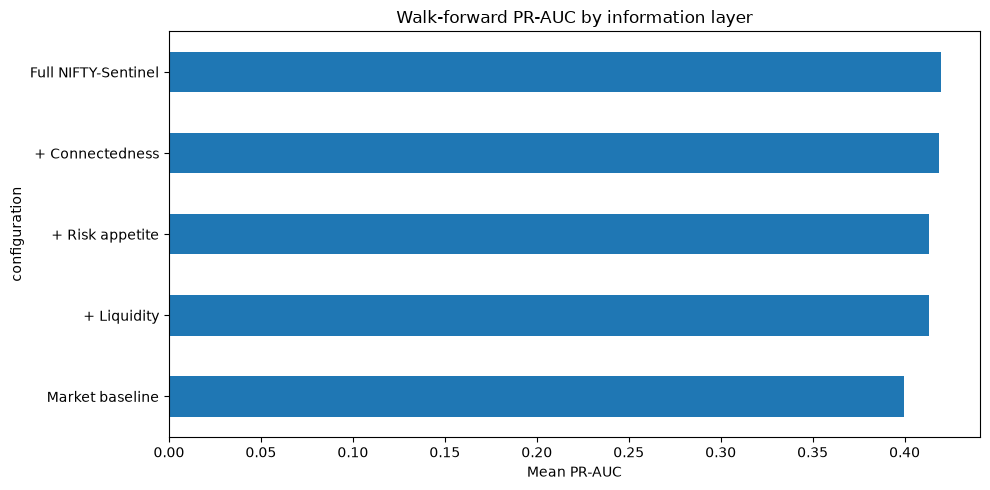

In [4]:
summary = ablation.groupby('configuration')['pr_auc'].mean().sort_values()
summary.plot(kind='barh', figsize=(10, 5), title='Walk-forward PR-AUC by information layer')
plt.xlabel('Mean PR-AUC')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ablation_pr_auc.png', dpi=180, bbox_inches='tight')
plt.show()

In [5]:
full_features = configurations['Full NIFTY-Sentinel']
final_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(n_estimators=800, min_samples_leaf=10, class_weight='balanced_subsample', random_state=42, n_jobs=-1)),
])
final_model.fit(labeled[full_features], y)
joblib.dump({'model': final_model, 'features': full_features, 'target': TARGET}, MODELS_DIR / 'full_nifty_sentinel.joblib')

imputed_full = final_model.named_steps['imputer'].transform(dataset[full_features])
sample_size = min(500, len(imputed_full))
imputed = imputed_full[-sample_size:]
tree = final_model.named_steps['model']
explainer = shap.TreeExplainer(tree)
shap_values = explainer.shap_values(imputed)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif getattr(shap_values, 'ndim', 0) == 3:
    shap_values = shap_values[:, :, 1]
latest_contributions = pd.Series(shap_values[-1], index=full_features).sort_values(key=abs, ascending=False)
latest_contributions.head(5)

volatility_20d             -0.219850
volatility_60d             -0.059526
mean_abs_correlation_60d    0.031443
volatility_5d              -0.029465
drawdown_60d               -0.026053
dtype: float64

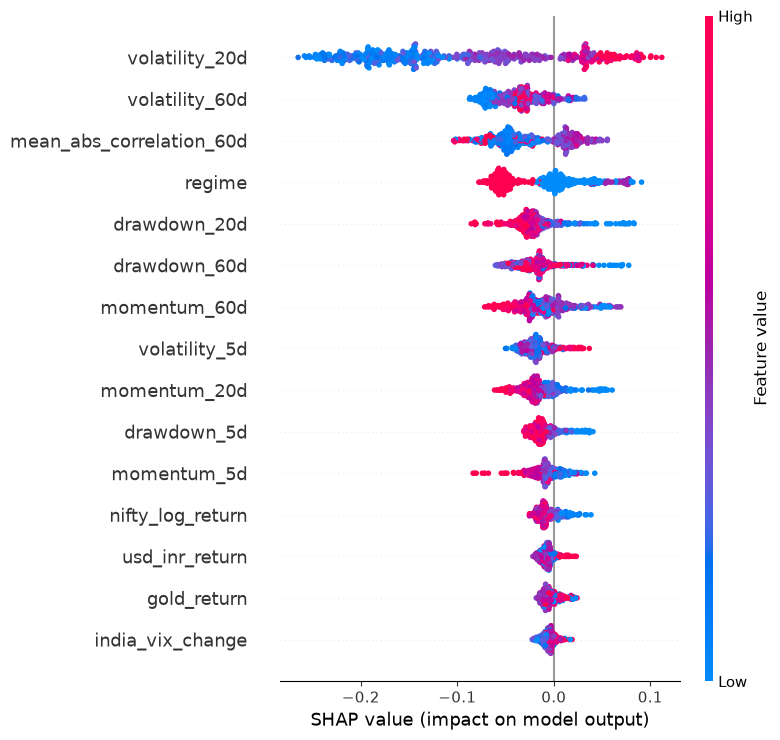

,nifty_close,regime,stress_probability,warning_level,driver_volatility_20d,driver_volatility_60d,driver_mean_abs_correlation_60d,driver_volatility_5d,driver_drawdown_60d
date,,,,,,,,,
2026-09-11,23398.099609,0.0,0.159889,Normal,<NA>,<NA>,<NA>,<NA>,<NA>
2026-09-15,23118.599609,0.0,0.165695,Normal,<NA>,<NA>,<NA>,<NA>,<NA>
2026-09-16,23217.599609,0.0,0.114232,Normal,<NA>,<NA>,<NA>,<NA>,<NA>
2026-09-17,23270.599609,0.0,0.100443,Normal,<NA>,<NA>,<NA>,<NA>,<NA>
2026-09-18,23346.400391,0.0,0.132143,Normal,-0.21985,-0.059526,0.031443,-0.029465,-0.026053


In [6]:
shap.summary_plot(shap_values, imputed, feature_names=full_features, show=False, max_display=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_feature_summary.png', dpi=180, bbox_inches='tight')
plt.show()

dashboard = dataset[['nifty_close', 'regime']].copy()
dashboard['stress_probability'] = final_model.predict_proba(dataset[full_features])[:, 1]
dashboard['warning_level'] = pd.cut(dashboard['stress_probability'], bins=[-0.01, 0.30, 0.60, 1.0], labels=['Normal', 'Elevated', 'Severe'])
for feature, contribution in latest_contributions.head(5).items():
    dashboard[f'driver_{feature}'] = pd.NA
    dashboard.iloc[-1, dashboard.columns.get_loc(f'driver_{feature}')] = contribution
dashboard.reset_index().to_csv(PROCESSED_DATA_DIR / 'dashboard_shap_export.csv', index=False)
dashboard.tail()

## Interpretation
Report ablation results even when the full model does not outperform the baseline. SHAP explains how the fitted model used inputs; it does not prove that a variable caused market stress.